# 📊 Visualizações
## TCC - Engenharia de Software

---

Este notebook gera **visualizações complementares** para apresentação dos resultados.

### Conteúdo:
- Gráficos de distribuição
- Gráficos de barras comparativos
- Histogramas
- Boxplots para variáveis Likert

---
## Configuração

In [ ]:
import sys; sys.path.append('../src')
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, utils

utils.configurar_visualizacoes()

try:
    df
    print("Usando dados já carregados")
except NameError:
    print("Carregando dados...")
    df = utils.carregar_dados('../dados/respostas.csv')
    print(f"{len(df)} respostas carregadas")

---
## Distribuição de Cargos

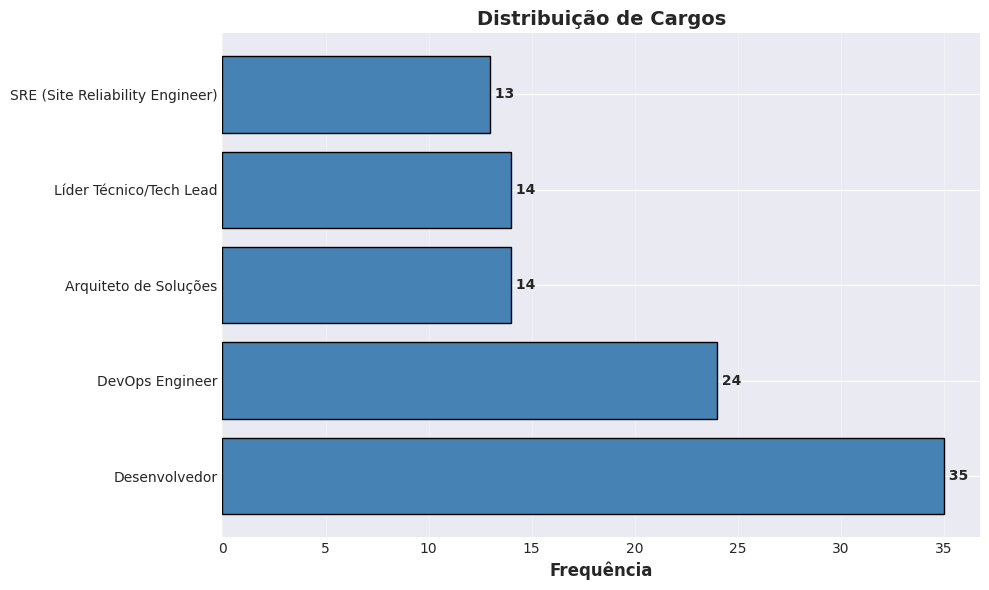


Gráfico salvo: resultados/graficos/descritivas/viz_cargos.png


In [2]:
import os

fig, ax = plt.subplots(figsize=(10, 6))

cargo_counts = df['q1_cargo'].value_counts()
ax.barh(cargo_counts.index, cargo_counts.values, color='steelblue', edgecolor='black')
ax.set_xlabel('Frequência', fontsize=12, fontweight='bold')
ax.set_title('Distribuição de Cargos', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(cargo_counts.values):
    ax.text(v, i, f" {v}", va='center', fontweight='bold')

plt.tight_layout()

os.makedirs('../resultados/graficos/descritivas', exist_ok=True)
caminho = '../resultados/graficos/descritivas/viz_cargos.png'
plt.savefig(caminho, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico salvo: {caminho}")

---
## Distribuição de Porte das Empresas

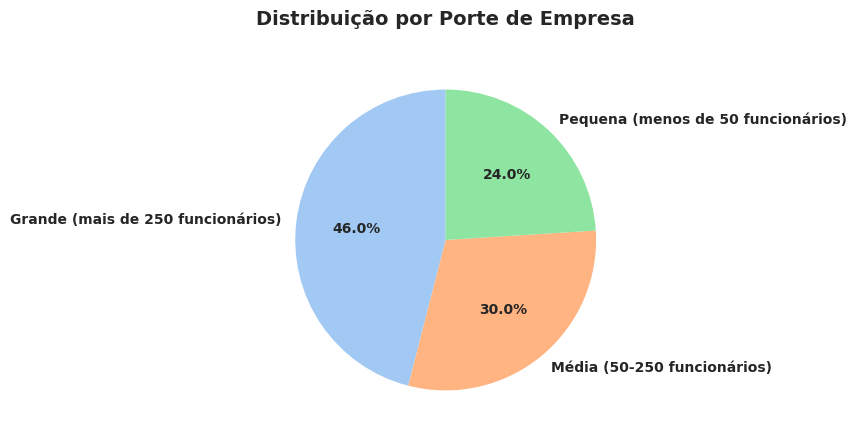


Gráfico salvo: resultados/graficos/descritivas/viz_porte_empresa.png


In [3]:
fig, ax = plt.subplots(figsize=(8, 8))

porte_counts = df['q6_porte_empresa'].value_counts()
colors = sns.color_palette('pastel')[0:len(porte_counts)]

ax.pie(porte_counts.values, labels=porte_counts.index, autopct='%1.1f%%',
       startangle=90, colors=colors, textprops={'fontweight': 'bold'})
ax.set_title('Distribuição por Porte de Empresa', fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()

caminho = '../resultados/graficos/descritivas/viz_porte_empresa.png'
plt.savefig(caminho, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico salvo: {caminho}")

---
## Desafios (Escala Likert)

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

desafios = {
    'Segurança': df['q12_desafio_seguranca'],
    'Complexidade': df['q13_desafio_complexidade'],
    'Monitoramento': df['q14_desafio_monitoramento'],
    'Mudanças Org.': df['q15_desafio_mudancas'],
    'Treinamento': df['q16_desafio_treinamento'],
    'CI/CD': df['q17_desafio_cicd']
}

df_desafios = pd.DataFrame(desafios)
df_desafios.boxplot(ax=ax, patch_artist=True)

ax.set_ylabel('Nível de Dificuldade (1-5)', fontsize=12, fontweight='bold')
ax.set_title('Distribuição dos Desafios (Escala Likert)', fontsize=14, fontweight='bold')
ax.set_ylim(0, 6)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

caminho = '../resultados/graficos/descritivas/viz_desafios_likert.png'
plt.savefig(caminho, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico salvo: {caminho}")

---
## Tempo Individual para se Sentir Confortável

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

tempo_counts = df['q24_tempo_individual'].value_counts()
ordem = ['Menos de 3 meses', '3-6 meses', '6-12 meses', '12-18 meses', 'Mais de 18 meses']
tempo_ordenado = tempo_counts.reindex(ordem, fill_value=0)

ax.bar(range(len(tempo_ordenado)), tempo_ordenado.values,
       color=sns.color_palette('Blues_d', len(tempo_ordenado)),
       edgecolor='black', linewidth=1.2)

ax.set_xticks(range(len(tempo_ordenado)))
ax.set_xticklabels(tempo_ordenado.index, rotation=45, ha='right')
ax.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax.set_title('Tempo Individual para se Sentir Confortável', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate(tempo_ordenado.values):
    ax.text(i, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

caminho = '../resultados/graficos/descritivas/viz_tempo_individual.png'
plt.savefig(caminho, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico salvo: {caminho}")

---
## ROI (Retorno sobre Investimento)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

roi_counts = df['q27_roi'].value_counts().sort_index()
colors = ['#d73027', '#fc8d59', '#fee08b', '#91cf60', '#1a9850']

ax.bar(roi_counts.index, roi_counts.values,
       color=[colors[int(i)-1] for i in roi_counts.index],
       edgecolor='black', linewidth=1.5)

ax.set_xlabel('Avaliação do ROI', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax.set_title('Distribuição da Avaliação do ROI\n(1=Muito Negativo, 5=Muito Positivo)',
             fontsize=14, fontweight='bold')
ax.set_xticks(roi_counts.index)
ax.grid(axis='y', alpha=0.3)

for i, (idx, v) in enumerate(roi_counts.items()):
    ax.text(idx, v, str(v), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()

caminho = '../resultados/graficos/descritivas/viz_roi.png'
plt.savefig(caminho, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico salvo: {caminho}")
print(f"\nMédia de ROI: {df['q27_roi'].mean():.2f}")
print(f"Mediana de ROI: {df['q27_roi'].median():.1f}")

---
## Principal Desafio por Porte de Empresa

In [ ]:
fig, ax = plt.subplots(figsize=(14, 8))

tabela = pd.crosstab(df['q6_porte_empresa'], df['q18_principal_desafio'])
tabela.plot(kind='bar', stacked=False, ax=ax, colormap='tab10', edgecolor='black')

ax.set_xlabel('Porte da Empresa', fontsize=12, fontweight='bold')
ax.set_ylabel('Frequência', fontsize=12, fontweight='bold')
ax.set_title('Principal Desafio por Porte de Empresa', fontsize=14, fontweight='bold')
ax.legend(title='Principal Desafio', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()

caminho = '../resultados/graficos/descritivas/viz_desafio_por_porte.png'
plt.savefig(caminho, dpi=300, bbox_inches='tight')
plt.show()

print(f"\nGráfico salvo: {caminho}")

In [8]:
utils.titulo_secao("Visualizações Concluídas")

print("\nGráficos salvos em resultados/graficos/descritivas/:")
print("   - viz_cargos.png")
print("   - viz_porte_empresa.png")
print("   - viz_desafios_likert.png")
print("   - viz_tempo_individual.png")
print("   - viz_roi.png")
print("   - viz_desafio_por_porte.png")
print("\nPipeline completa de análises finalizada!")


VISUALIZAÇÕES CONCLUÍDAS

Gráficos salvos em resultados/graficos/descritivas/:
   - viz_cargos.png
   - viz_porte_empresa.png
   - viz_desafios_likert.png
   - viz_tempo_individual.png
   - viz_roi.png
   - viz_desafio_por_porte.png

Pipeline completa de análises finalizada!
